# heat1d: CLI & Parameter Fitting Demo

This notebook accompanies the presentation on the `heat1d` 1D thermal model for airless bodies.

**Contents:**
1. CLI examples — running the model from the command line
2. Loading Diviner nighttime regolith temperature data
3. Fitting the H-parameter to Diviner data using `scipy.optimize`
4. Visualizing fit sensitivity with a grid search
5. Effect of surface conductivity on the H-parameter fit

## 1. CLI Demo

The `heat1d` command-line tool runs a thermal model with sensible defaults. Use `--help` to see all options:

In [13]:
!heat1d --help

Usage: heat1d [OPTIONS] [CONFIG_FILE]

  Run the heat1d 1-D thermal model.

  Optionally accepts a YAML configuration file. Command-line options override
  values from the file.

  Examples:
      heat1d                              # Moon equator, defaults
      heat1d --lat 45 --solver implicit   # Moon 45N, implicit solver
      heat1d moon.yaml --lat 30           # YAML config, override lat
      heat1d --validate                   # Run validation suite
      heat1d --backend c --lat 0          # Run C backend at equator
      heat1d --validate-c                 # Run C validation tests
      heat1d --compare --solver explicit  # Compare C vs Python
      heat1d --use-spice --lat 0 --lon 0 --start-time "2024-06-15 12:00" --ndays 1

Options:
  --lat FLOAT                     Latitude [degrees].
  --ndays INTEGER                 Number of output days.
  --solver [explicit|crank-nicolson|implicit|fourier-matrix]
                                  Solver scheme.
  --planet TEXT        

Run a quick equatorial simulation (1 lunation, explicit solver):

In [14]:
!heat1d --lat 0 --solver explicit --no-plot

heat1d v0.4.0
  Planet:   Moon
  Latitude: 0.0 deg
  Days:     1
  Solver:   explicit
  Output:   every 0.5 hr (53155 s)
  Chi:      2.7
Running model (backend=python)...
Done.
  Temperature data: output/heat1d_temperature.csv
  Grid data:        output/heat1d_grid.csv

  T_max  = 388.11 K
  T_min  = 91.23 K
  T_mean = 210.26 K


### More CLI examples

Thermophysical properties and grid parameters are set via a YAML config file.
Here we create a config with mare albedo and lowered surface conductivity,
then run at 30° latitude with the implicit solver:

In [ ]:
%%writefile /tmp/mare_example.yaml
# Mare regolith with lowered surface conductivity
planet:
  name: Moon
  albedo: 0.06        # mare basalt (vs 0.12 highland)
  ks: 0.00037         # half the standard K_s [W/m/K]
  H: 0.06             # density scale height [m]

solver: implicit
m: 15                 # finer grid (15 layers per skin depth)
n: 6                  # layer growth factor
NYEARSEQ: 3           # 3-orbit equilibration

In [ ]:
!heat1d /tmp/mare_example.yaml --lat 30 --no-plot

CLI options can also override YAML values. For example, switch the albedo
back to highland and change the solver on the fly:

In [ ]:
# Override albedo and solver from the command line
!heat1d /tmp/mare_example.yaml --lat 30 --albedo 0.12 --solver crank-nicolson --no-plot

## 2. Loading Diviner Nighttime Regolith Temperature Data

The Diviner Lunar Radiometer measured nighttime surface temperatures across the Moon.
We have data at three latitudes (0, 30, 60 deg) showing temperature vs. local time during the lunar night.

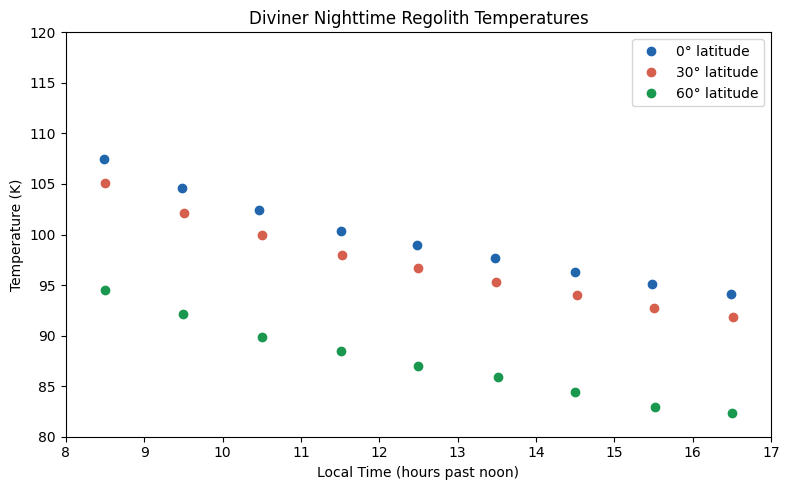

In [16]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

# Load Diviner nighttime regolith temperature data
data_dir = "../../data"
diviner = {}
for lat in [0, 30, 60]:
    df = pd.read_csv(f"{data_dir}/diviner_regtemp_lat{lat:02d}.csv", skipinitialspace=True)
    diviner[lat] = {"lt": df["x"].values, "T": df["y"].values}

# Plot the observations
fig, ax = plt.subplots(figsize=(8, 5))
colors = {0: "#2166ac", 30: "#d6604d", 60: "#1a9850"}
for lat in [0, 30, 60]:
    ax.plot(diviner[lat]["lt"], diviner[lat]["T"], "o", color=colors[lat],
            ms=6, label=f"{lat}° latitude")
ax.set_xlabel("Local Time (hours past noon)")
ax.set_ylabel("Temperature (K)")
ax.set_title("Diviner Nighttime Regolith Temperatures")
ax.legend()
ax.set_xlim(8, 17)
ax.set_ylim(80, 120)
plt.tight_layout()
plt.show()

## 3. Fitting the H-Parameter

The density scale height $H$ controls how quickly regolith density (and thermal conductivity)
increase with depth:

$$\rho(z) = \rho_d - (\rho_d - \rho_s)\,e^{-z/H}$$

A larger $H$ means the low-conductivity surface layer extends deeper, producing cooler nighttime
temperatures. We fit $H$ by minimizing the RMS difference between the model and Diviner data.

In [17]:
import copy
from scipy.interpolate import interp1d
from scipy.optimize import minimize_scalar
import planets
from heat1d import Model, Configurator


def run_model_nighttime_T(H, lat_deg, ks=None, nyearseq=5):
    """Run a Moon model and return nighttime surface temperatures.

    Parameters
    ----------
    H : float
        Density/conductivity scale height [m].
    lat_deg : float
        Latitude [degrees].
    ks : float, optional
        Surface conductivity [W/m/K]. None uses the default (7.4e-4).
    nyearseq : int
        Number of equilibration orbits.

    Returns
    -------
    model : Model
        Completed model instance.
    """
    planet = copy.copy(planets.Moon)
    planet.H = H
    if ks is not None:
        planet.ks = ks
    config = Configurator(solver="explicit", NYEARSEQ=nyearseq)
    model = Model(planet=planet, lat=np.deg2rad(lat_deg), ndays=1, config=config)
    model.run()
    return model


def rms_misfit(H, lat_deg, obs_lt, obs_T, ks=None):
    """Compute RMS difference between model and observed nighttime T."""
    model = run_model_nighttime_T(H, lat_deg, ks=ks)
    # Interpolate model onto observation local times
    f = interp1d(model.lt, model.T[:, 0], kind="linear")
    T_model = f(obs_lt)
    return np.sqrt(np.mean((T_model - obs_T) ** 2))

### Fit at the equator with standard parameters

In [18]:
# Fit H at the equator using standard K_s
lat_fit = 0
obs = diviner[lat_fit]

result = minimize_scalar(
    rms_misfit, bounds=(0.01, 0.20), method="bounded",
    args=(lat_fit, obs["lt"], obs["T"]),
)

H_best = result.x
rms_best = result.fun
print(f"Best-fit H = {H_best:.4f} m")
print(f"RMS misfit  = {rms_best:.2f} K")
print(f"(Hayne et al. 2017 standard: H = 0.06 m)")

Best-fit H = 0.0560 m
RMS misfit  = 0.16 K
(Hayne et al. 2017 standard: H = 0.06 m)


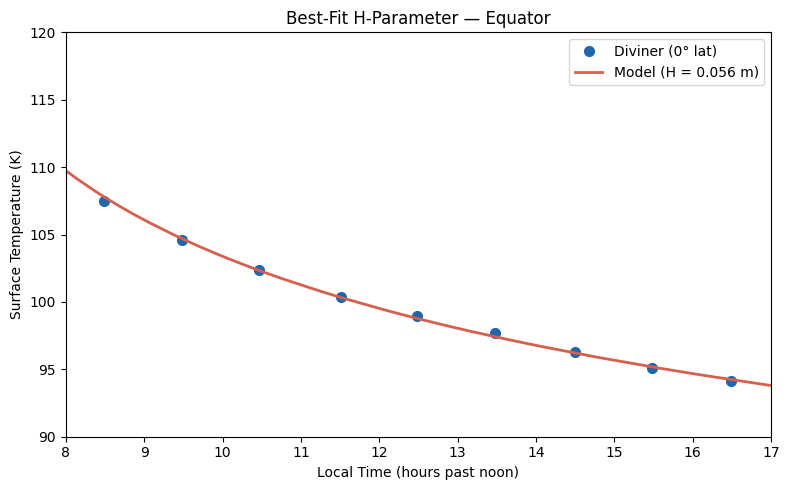

In [19]:
# Plot best-fit model vs Diviner data
model_best = run_model_nighttime_T(H_best, lat_fit)

fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(obs["lt"], obs["T"], "o", color="#2166ac", ms=7, label="Diviner (0° lat)")
ax.plot(model_best.lt, model_best.T[:, 0], "-", color="#d6604d", lw=2,
        label=f"Model (H = {H_best:.3f} m)")
ax.set_xlabel("Local Time (hours past noon)")
ax.set_ylabel("Surface Temperature (K)")
ax.set_title("Best-Fit H-Parameter — Equator")
ax.set_xlim(8, 17)
ax.set_ylim(90, 120)
ax.legend()
plt.tight_layout()
plt.show()

## 4. Grid Search — RMS vs H at All Latitudes

Sweep $H$ across a range and compute the RMS misfit at each latitude to visualize the sensitivity.

In [20]:
H_values = np.linspace(0.02, 0.18, 17)
rms_grid = {lat: [] for lat in [0, 30, 60]}

for H in H_values:
    for lat in [0, 30, 60]:
        obs = diviner[lat]
        rms = rms_misfit(H, lat, obs["lt"], obs["T"])
        rms_grid[lat].append(rms)
    print(f"  H = {H:.3f} m done")

for lat in rms_grid:
    rms_grid[lat] = np.array(rms_grid[lat])

  H = 0.020 m done
  H = 0.030 m done
  H = 0.040 m done
  H = 0.050 m done
  H = 0.060 m done
  H = 0.070 m done
  H = 0.080 m done
  H = 0.090 m done
  H = 0.100 m done
  H = 0.110 m done
  H = 0.120 m done
  H = 0.130 m done
  H = 0.140 m done
  H = 0.150 m done
  H = 0.160 m done
  H = 0.170 m done
  H = 0.180 m done


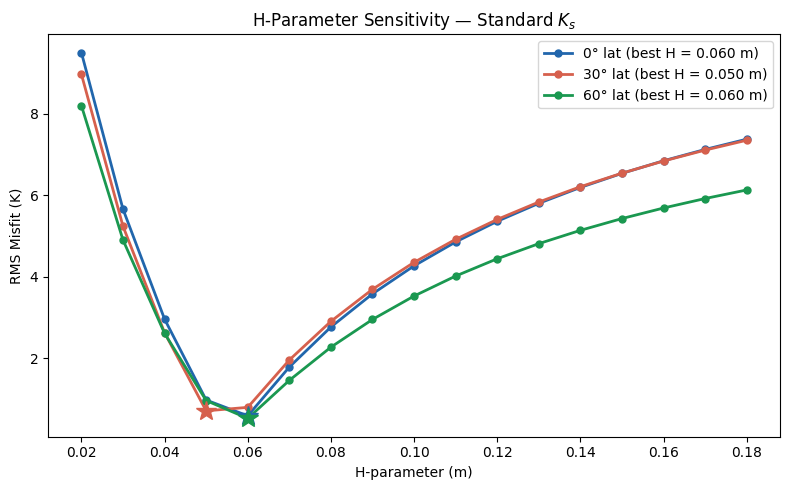

In [21]:
fig, ax = plt.subplots(figsize=(8, 5))
for lat in [0, 30, 60]:
    rms = rms_grid[lat]
    i_min = np.argmin(rms)
    ax.plot(H_values, rms, "o-", color=colors[lat], lw=2, ms=5,
            label=f"{lat}° lat (best H = {H_values[i_min]:.3f} m)")
    ax.plot(H_values[i_min], rms[i_min], "*", color=colors[lat], ms=15,
            zorder=5)

ax.set_xlabel("H-parameter (m)")
ax.set_ylabel("RMS Misfit (K)")
ax.set_title("H-Parameter Sensitivity — Standard $K_s$")
ax.legend()
plt.tight_layout()
plt.show()

## 5. Effect of Surface Conductivity on the H-Parameter Fit

What happens when we lower $K_s$ by a factor of 2? A more insulating surface layer changes the
nighttime cooling curve, requiring a different $H$ to match the Diviner observations.

In [22]:
ks_standard = planets.Moon.ks           # 7.4e-4 W/m/K
ks_low = ks_standard / 2.0              # 3.7e-4 W/m/K
print(f"Standard K_s = {ks_standard:.4e} W/m/K")
print(f"Low K_s      = {ks_low:.4e} W/m/K")

# Fit H at equator with low K_s
obs_eq = diviner[0]
result_low = minimize_scalar(
    rms_misfit, bounds=(0.01, 0.20), method="bounded",
    args=(0, obs_eq["lt"], obs_eq["T"], ks_low),
)

H_best_low = result_low.x
rms_best_low = result_low.fun
print(f"\nStandard K_s:  best-fit H = {H_best:.4f} m,  RMS = {rms_best:.2f} K")
print(f"Low K_s (0.5x): best-fit H = {H_best_low:.4f} m,  RMS = {rms_best_low:.2f} K")

Standard K_s = 7.4000e-04 W/m/K
Low K_s      = 3.7000e-04 W/m/K

Standard K_s:  best-fit H = 0.0560 m,  RMS = 0.16 K
Low K_s (0.5x): best-fit H = 0.0404 m,  RMS = 0.49 K


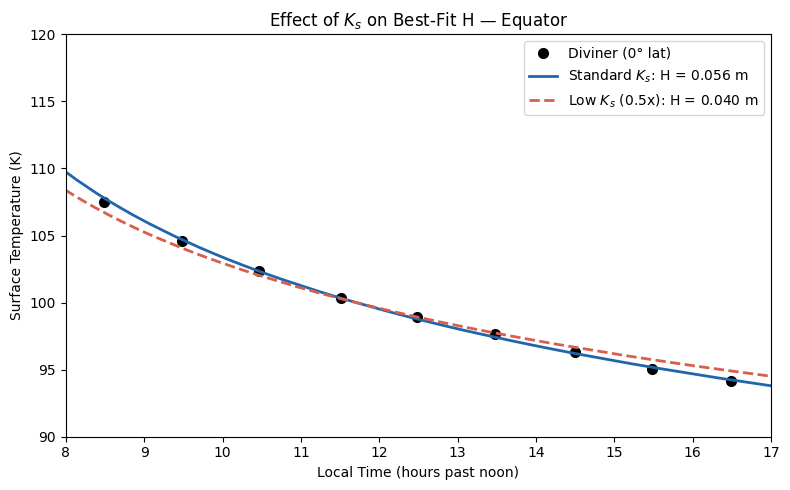

In [23]:
# Compare both fits against Diviner data
model_std = run_model_nighttime_T(H_best, 0)
model_low = run_model_nighttime_T(H_best_low, 0, ks=ks_low)

fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(obs_eq["lt"], obs_eq["T"], "ko", ms=7, label="Diviner (0° lat)")
ax.plot(model_std.lt, model_std.T[:, 0], "-", color="#2166ac", lw=2,
        label=f"Standard $K_s$: H = {H_best:.3f} m")
ax.plot(model_low.lt, model_low.T[:, 0], "--", color="#d6604d", lw=2,
        label=f"Low $K_s$ (0.5x): H = {H_best_low:.3f} m")
ax.set_xlabel("Local Time (hours past noon)")
ax.set_ylabel("Surface Temperature (K)")
ax.set_title("Effect of $K_s$ on Best-Fit H — Equator")
ax.set_xlim(8, 17)
ax.set_ylim(90, 120)
ax.legend()
plt.tight_layout()
plt.show()

In [24]:
# Grid search comparison: standard vs low K_s
rms_grid_low = {lat: [] for lat in [0, 30, 60]}

for H in H_values:
    for lat in [0, 30, 60]:
        obs = diviner[lat]
        rms = rms_misfit(H, lat, obs["lt"], obs["T"], ks=ks_low)
        rms_grid_low[lat].append(rms)
    print(f"  H = {H:.3f} m done")

for lat in rms_grid_low:
    rms_grid_low[lat] = np.array(rms_grid_low[lat])

  H = 0.020 m done
  H = 0.030 m done
  H = 0.040 m done
  H = 0.050 m done
  H = 0.060 m done
  H = 0.070 m done
  H = 0.080 m done
  H = 0.090 m done
  H = 0.100 m done
  H = 0.110 m done
  H = 0.120 m done
  H = 0.130 m done
  H = 0.140 m done
  H = 0.150 m done
  H = 0.160 m done
  H = 0.170 m done
  H = 0.180 m done


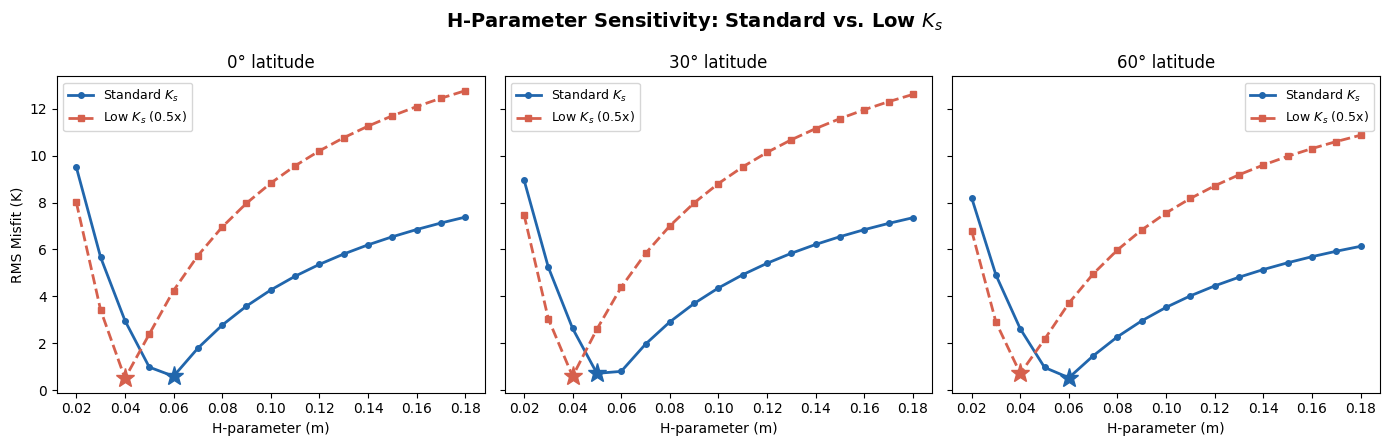

In [25]:
fig, axes = plt.subplots(1, 3, figsize=(14, 4.5), sharey=True)

for i, lat in enumerate([0, 30, 60]):
    ax = axes[i]
    # Standard K_s
    rms_std = rms_grid[lat]
    ax.plot(H_values, rms_std, "o-", color="#2166ac", lw=2, ms=4,
            label=f"Standard $K_s$")
    i_min = np.argmin(rms_std)
    ax.plot(H_values[i_min], rms_std[i_min], "*", color="#2166ac", ms=14, zorder=5)

    # Low K_s
    rms_lo = rms_grid_low[lat]
    ax.plot(H_values, rms_lo, "s--", color="#d6604d", lw=2, ms=4,
            label=f"Low $K_s$ (0.5x)")
    i_min_lo = np.argmin(rms_lo)
    ax.plot(H_values[i_min_lo], rms_lo[i_min_lo], "*", color="#d6604d", ms=14, zorder=5)

    ax.set_xlabel("H-parameter (m)")
    ax.set_title(f"{lat}° latitude")
    if i == 0:
        ax.set_ylabel("RMS Misfit (K)")
    ax.legend(fontsize=9)

fig.suptitle("H-Parameter Sensitivity: Standard vs. Low $K_s$", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()

## Summary

- The H-parameter controls the depth-dependent density and conductivity transition from loose surface regolith to compacted material at depth.
- Fitting H to Diviner nighttime cooling curves yields values consistent with the Hayne et al. (2017) global average ($H \approx 0.06$ m).
- **Lowering $K_s$ by 2x shifts the best-fit H** — a more insulating surface layer requires a different density profile to match the observed nighttime temperatures.
- This demonstrates the **trade-off between $K_s$ and $H$**: both control the effective thermal inertia of the upper regolith, and independent constraints are needed to break the degeneracy.